In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [74]:
df = pd.read_csv("customerData_500k.csv")

df.head()

,Age,AnnualIncome,NumberOfPurchases,TimeSpentOnWebsite,CustomerTenureYears,LastPurchaseDaysAgo,Gender,ProductCategory,PreferredDevice,Region,ReferralSource,CustomerSegment,LoyaltyProgram,DiscountsAvailed,SessionCount,CustomerSatisfaction,PurchaseStatus
0,37,57722.572411,19,5.908826,1.093430,11,Male,Furniture,Desktop,South,Paid Ads,Regular,1,5,3,2,1
1,63,21328.925876,10,6.970749,0.649246,20,Female,Furniture,Mobile,East,Organic,VIP,0,4,2,3,0
2,60,150537.742465,19,35.004954,3.858211,25,Male,Electronics,Desktop,South,Organic,VIP,1,2,5,2,0
3,19,63508.762549,10,14.818000,7.554374,20,Male,Furniture,Desktop,West,Paid Ads,Premium,0,0,1,3,0
4,54,100399.558368,19,55.925462,0.197411,92,Male,Electronics,Mobile,South,Referral,Regular,1,4,1,2,0


In [75]:
print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nFirst 5 Rows:")
print(df.head())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Dataset Shape:
(500000, 17)

Column Names:
Index(['Age', 'AnnualIncome', 'NumberOfPurchases', 'TimeSpentOnWebsite',
       'CustomerTenureYears', 'LastPurchaseDaysAgo', 'Gender',
       'ProductCategory', 'PreferredDevice', 'Region', 'ReferralSource',
       'CustomerSegment', 'LoyaltyProgram', 'DiscountsAvailed', 'SessionCount',
       'CustomerSatisfaction', 'PurchaseStatus'],
      dtype='object')

Data Types:
Age                       int64
AnnualIncome            float64
NumberOfPurchases         int64
TimeSpentOnWebsite      float64
CustomerTenureYears     float64
LastPurchaseDaysAgo       int64
Gender                   object
ProductCategory          object
PreferredDevice          object
Region                   object
ReferralSource           object
CustomerSegment          object
LoyaltyProgram            int64
DiscountsAvailed          int64
SessionCount              int64
CustomerSatisfaction      int64
PurchaseStatus            int64
dtype: object

First 5 Rows:
   Age   A

In [76]:
# Create a copy
cleaned_df = df.copy()

# Check missing values
print("Missing values per column:")
print(cleaned_df.isnull().sum())

# Fill missing values if any
cleaned_df.fillna(0, inplace=True)

# Check duplicates
print("\nDuplicate rows:", cleaned_df.duplicated().sum())

# Drop duplicates if any
cleaned_df.drop_duplicates(inplace=True)

print("Duplicate rows after removal:", cleaned_df.duplicated().sum())

print("\nCleaned dataset shape:")
print(cleaned_df.shape)

Missing values per column:
Age                     0
AnnualIncome            0
NumberOfPurchases       0
TimeSpentOnWebsite      0
CustomerTenureYears     0
LastPurchaseDaysAgo     0
Gender                  0
ProductCategory         0
PreferredDevice         0
Region                  0
ReferralSource          0
CustomerSegment         0
LoyaltyProgram          0
DiscountsAvailed        0
SessionCount            0
CustomerSatisfaction    0
PurchaseStatus          0
dtype: int64

Duplicate rows: 0
Duplicate rows after removal: 0

Cleaned dataset shape:
(500000, 17)


In [77]:
categorical_cols = ['Gender', 'ProductCategory', 'PreferredDevice',
                    'Region', 'ReferralSource', 'CustomerSegment']

le = LabelEncoder()

for col in categorical_cols:
    cleaned_df[col] = le.fit_transform(cleaned_df[col])

print(cleaned_df.head())

   Age   AnnualIncome  NumberOfPurchases  TimeSpentOnWebsite  \
0   37   57722.572411                 19            5.908826   
1   63   21328.925876                 10            6.970749   
2   60  150537.742465                 19           35.004954   
3   19   63508.762549                 10           14.818000   
4   54  100399.558368                 19           55.925462   

   CustomerTenureYears  LastPurchaseDaysAgo  Gender  ProductCategory  \
0             1.093430                   11       1                2   
1             0.649246                   20       0                2   
2             3.858211                   25       1                0   
3             7.554374                   20       1                2   
4             0.197411                   92       1                0   

   PreferredDevice  Region  ReferralSource  CustomerSegment  LoyaltyProgram  \
0                0       2               2                1               1   
1                1      

In [78]:
print("\nBasic Statistics:")
print(cleaned_df.describe())


Basic Statistics:
                 Age   AnnualIncome  NumberOfPurchases  TimeSpentOnWebsite  \
count  500000.000000  500000.000000      500000.000000       500000.000000   
mean       43.941044   85071.804966          11.387584           30.594395   
std        15.756232   39586.271859           6.000702           17.585290   
min        15.000000   11966.385655          -1.000000           -3.804161   
25%        30.000000   51998.815726           6.000000           15.843041   
50%        44.000000   83748.351846          12.000000           30.763164   
75%        57.000000  116554.694607          16.000000           45.012866   
max        81.000000  204178.294436          28.000000           78.364251   

       CustomerTenureYears  LastPurchaseDaysAgo         Gender  \
count        500000.000000        500000.000000  500000.000000   
mean              2.163483            60.191362       0.505120   
std               2.197354            54.886826       0.499974   
min           

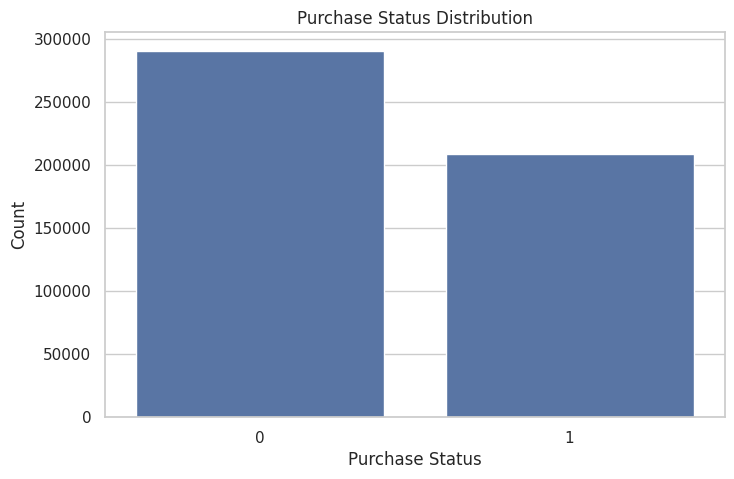

In [79]:
plt.figure(figsize=(8,5))
sns.countplot(x='PurchaseStatus', data=cleaned_df)
plt.title("Purchase Status Distribution")
plt.xlabel("Purchase Status")
plt.ylabel("Count")
plt.show()

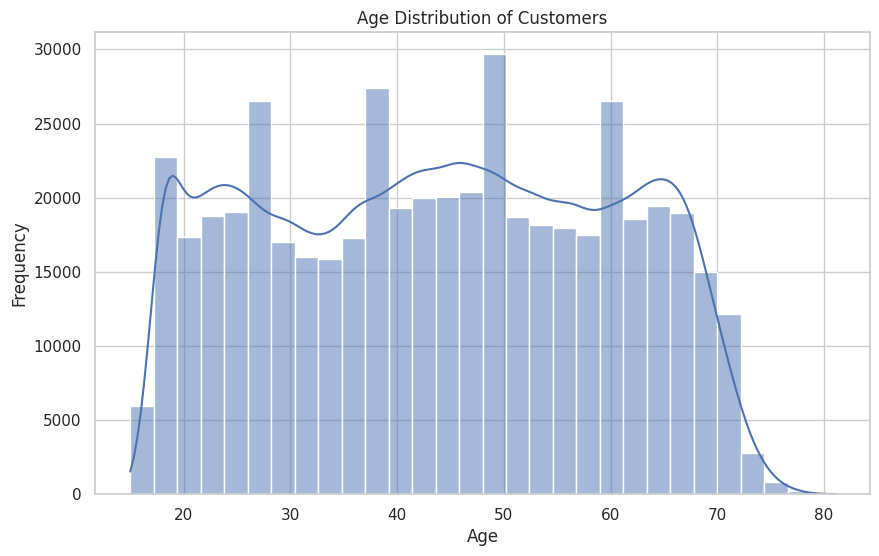

In [80]:
plt.figure(figsize=(10,6))
sns.histplot(cleaned_df['Age'], bins=30, kde=True)
plt.title("Age Distribution of Customers")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

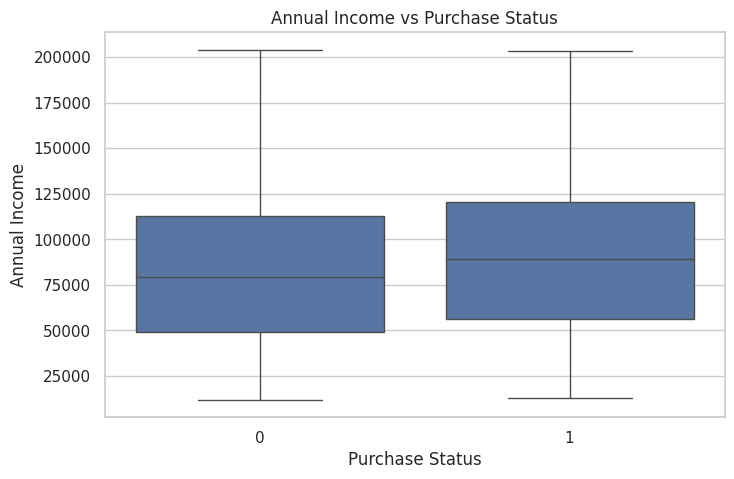

In [81]:
plt.figure(figsize=(8,5))
sns.boxplot(x='PurchaseStatus', y='AnnualIncome', data=cleaned_df)
plt.title("Annual Income vs Purchase Status")
plt.xlabel("Purchase Status")
plt.ylabel("Annual Income")
plt.show()

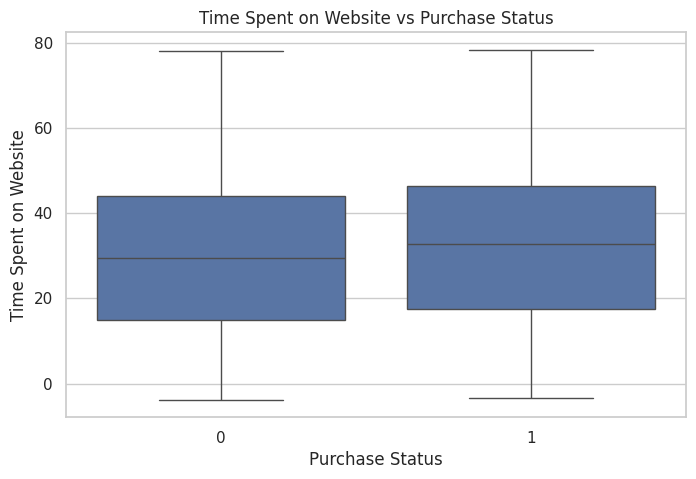

In [82]:
plt.figure(figsize=(8,5))
sns.boxplot(x='PurchaseStatus', y='TimeSpentOnWebsite', data=cleaned_df)
plt.title("Time Spent on Website vs Purchase Status")
plt.xlabel("Purchase Status")
plt.ylabel("Time Spent on Website")
plt.show()

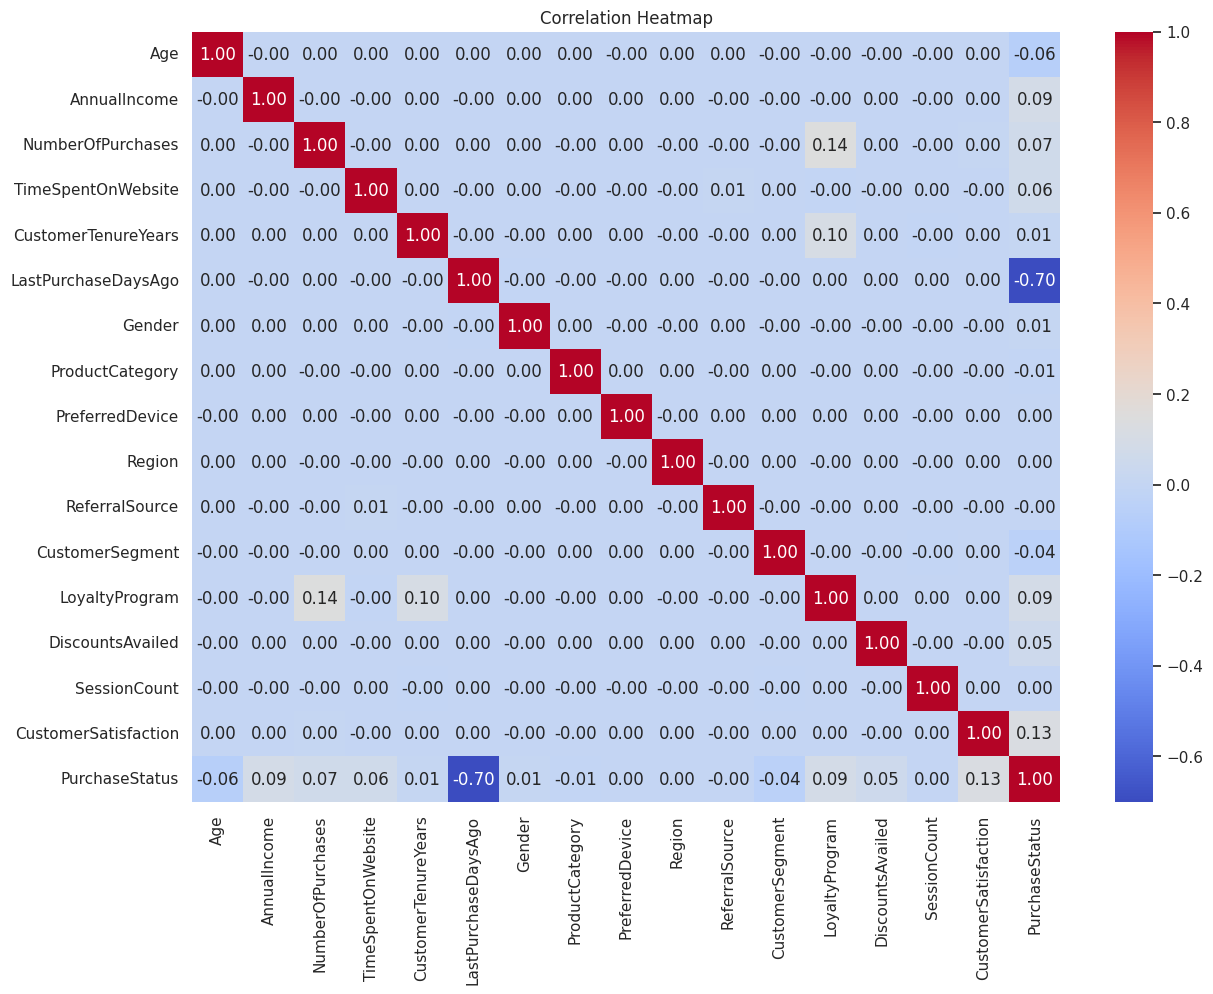

In [85]:

plt.figure(figsize=(14,10))
sns.heatmap(cleaned_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap")
plt.show()

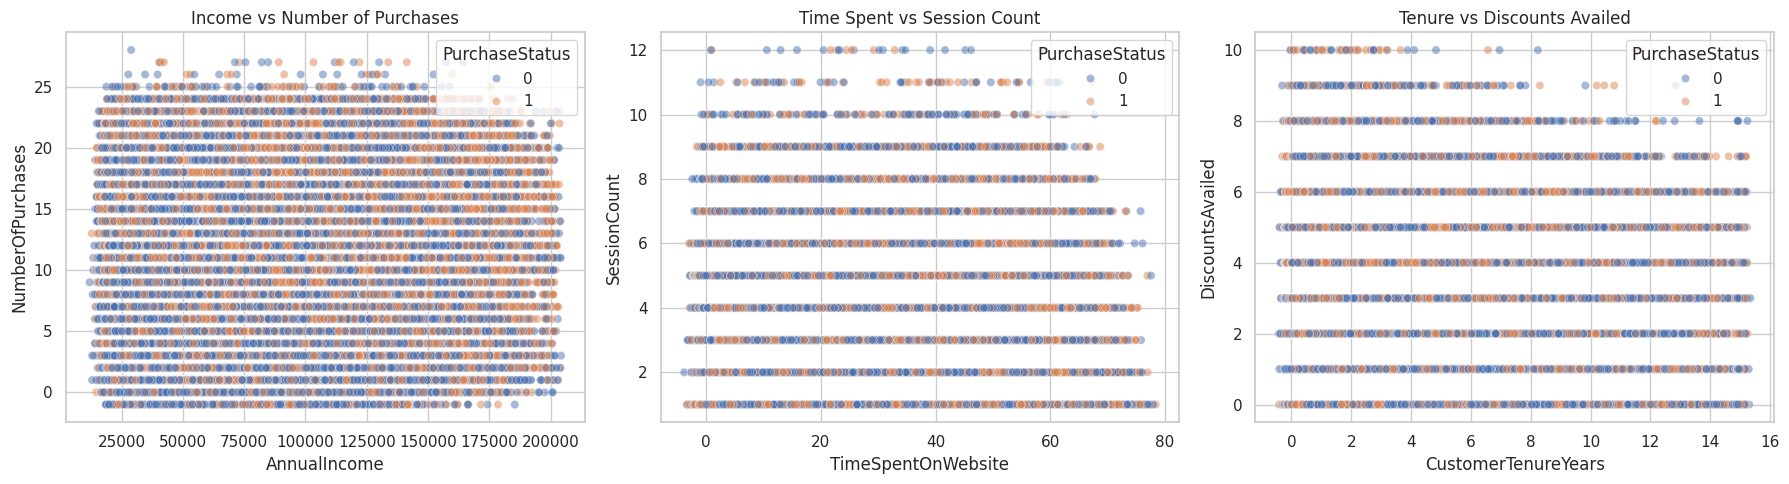

In [86]:
plt.figure(figsize=(18,5))

# Plot 1
plt.subplot(1,3,1)
sns.scatterplot(x='AnnualIncome', y='NumberOfPurchases', data=cleaned_df,
                hue='PurchaseStatus', alpha=0.5)
plt.title("Income vs Number of Purchases")

# Plot 2
plt.subplot(1,3,2)
sns.scatterplot(x='TimeSpentOnWebsite', y='SessionCount', data=cleaned_df,
                hue='PurchaseStatus', alpha=0.5)
plt.title("Time Spent vs Session Count")

# Plot 3
plt.subplot(1,3,3)
sns.scatterplot(x='CustomerTenureYears', y='DiscountsAvailed', data=cleaned_df,
                hue='PurchaseStatus', alpha=0.5)
plt.title("Tenure vs Discounts Availed")

plt.tight_layout()
plt.show()

In [87]:
# Select features and target
X = cleaned_df[['Age',
                'AnnualIncome',
                'NumberOfPurchases',
                'TimeSpentOnWebsite',
                'CustomerTenureYears',
                'LastPurchaseDaysAgo',
                'Gender',
                'ProductCategory',
                'PreferredDevice',
                'Region',
                'ReferralSource',
                'CustomerSegment',
                'LoyaltyProgram',
                'DiscountsAvailed',
                'SessionCount',
                'CustomerSatisfaction']]

y = cleaned_df['PurchaseStatus']

In [88]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=88
)

In [89]:
lr_model = LogisticRegression(max_iter=1000, random_state=88)
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

print("\nLogistic Regression Performance:")
print("Accuracy:", accuracy_score(y_test, lr_pred))
print("Precision:", precision_score(y_test, lr_pred, zero_division=0))
print("Recall:", recall_score(y_test, lr_pred, zero_division=0))
print("F1 Score:", f1_score(y_test, lr_pred, zero_division=0))

print("\nClassification Report:")
print(classification_report(y_test, lr_pred, zero_division=0))


Logistic Regression Performance:
Accuracy: 0.9226
Precision: 0.88945653670251
Recall: 0.9299090080437529
F1 Score: 0.9092330544914393

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.92      0.93     87467
           1       0.89      0.93      0.91     62533

    accuracy                           0.92    150000
   macro avg       0.92      0.92      0.92    150000
weighted avg       0.92      0.92      0.92    150000



In [90]:
dt_model = DecisionTreeClassifier(random_state=88)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)

print("\nDecision Tree Classifier Performance:")
print("Accuracy:", accuracy_score(y_test, dt_pred))
print("Precision:", precision_score(y_test, dt_pred, zero_division=0))
print("Recall:", recall_score(y_test, dt_pred, zero_division=0))
print("F1 Score:", f1_score(y_test, dt_pred, zero_division=0))

print("\nClassification Report:")
print(classification_report(y_test, dt_pred, zero_division=0))


Decision Tree Classifier Performance:
Accuracy: 0.88774
Precision: 0.8679895628644139
Recall: 0.8617849775318632
F1 Score: 0.8648761424822861

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.91      0.90     87467
           1       0.87      0.86      0.86     62533

    accuracy                           0.89    150000
   macro avg       0.88      0.88      0.88    150000
weighted avg       0.89      0.89      0.89    150000



In [91]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=88)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

print("\nRandom Forest Classifier Performance:")
print("Accuracy:", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred, zero_division=0))
print("Recall:", recall_score(y_test, rf_pred, zero_division=0))
print("F1 Score:", f1_score(y_test, rf_pred, zero_division=0))

print("\nClassification Report:")
print(classification_report(y_test, rf_pred, zero_division=0))


Random Forest Classifier Performance:
Accuracy: 0.9238466666666667
Precision: 0.890510391198044
Recall: 0.9319079526010267
F1 Score: 0.9107389840044384

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.92      0.93     87467
           1       0.89      0.93      0.91     62533

    accuracy                           0.92    150000
   macro avg       0.92      0.92      0.92    150000
weighted avg       0.92      0.92      0.92    150000



In [92]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Accuracy': [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred)
    ],
    'Precision': [
        precision_score(y_test, lr_pred, zero_division=0),
        precision_score(y_test, dt_pred, zero_division=0),
        precision_score(y_test, rf_pred, zero_division=0)
    ],
    'Recall': [
        recall_score(y_test, lr_pred, zero_division=0),
        recall_score(y_test, dt_pred, zero_division=0),
        recall_score(y_test, rf_pred, zero_division=0)
    ],
    'F1 Score': [
        f1_score(y_test, lr_pred, zero_division=0),
        f1_score(y_test, dt_pred, zero_division=0),
        f1_score(y_test, rf_pred, zero_division=0)
    ]
})

print("\nModel Comparison Table:")
print(results)


Model Comparison Table:
                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.922600   0.889457  0.929909  0.909233
1        Decision Tree  0.887740   0.867990  0.861785  0.864876
2        Random Forest  0.923847   0.890510  0.931908  0.910739


In [93]:
best_model = results.loc[results['F1 Score'].idxmax()]
print("\nBest Model Based on F1 Score:")
print(best_model)


Best Model Based on F1 Score:
Model        Random Forest
Accuracy          0.923847
Precision          0.89051
Recall            0.931908
F1 Score          0.910739
Name: 2, dtype: object
